# **Lab 11**
# **From Pixels to Predictions**

# Building Your First Image Classifier with Transfer Learning

**Kaggle Notebook  ·  PyTorch  ·  ResNet18  ·  CIFAR-10 Mini  ·  GitHub**


# **Section 1: Kaggle Setup & Environment**

# ─── Cell 1: Install extra packages ────

In [1]:
# Kaggle already has:
# torch, torchvision, numpy, matplotlib

# Install extra libraries
!pip install -q scikit-learn
!pip install -q seaborn

print('All extra packages installed!')

All extra packages installed!


# ─── Cell 2: Import all required libraries ────

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets

from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import os
import warnings

warnings.filterwarnings('ignore')

# ── Detect device ─────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device in use : {device}')
print(f'PyTorch version: {torch.__version__}')

Device in use : cuda
PyTorch version: 2.10.0+cu128


# **Section 2: Dataset & Preprocessing**

# ─── Cell 3: Define transforms for training and validation ────

In [3]:
# TRAINING TRANSFORMS (with augmentation)

train_transform = transforms.Compose([

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),

    transforms.RandomCrop(32, padding=4),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# VALIDATION / TEST TRANSFORMS

val_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('Transforms defined successfully!')
print('Training : resize + augmentation + normalize')
print('Validation: resize + normalize only')

Transforms defined successfully!
Training : resize + augmentation + normalize
Validation: resize + normalize only


# ─── Cell 4: Download CIFAR-10 and create mini subset ────

In [6]:
print('Downloading CIFAR-10 dataset...')

# Download full datasets
full_train_raw = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

full_test_raw = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=val_transform
)

print(f'Full training set: {len(full_train_raw):,} images')
print(f'Full test set    : {len(full_test_raw):,} images')

# Helper function
import random

random.seed(42)

def make_balanced_subset(dataset, n_per_class=500, num_classes=10):

    targets = dataset.targets

    indices_per_class = {c: [] for c in range(num_classes)}

    for idx, label in enumerate(targets):
        indices_per_class[label].append(idx)

    selected = []

    for c in range(num_classes):

        pool = indices_per_class[c]

        random.shuffle(pool)

        selected.extend(pool[:n_per_class])

    random.shuffle(selected)

    return Subset(dataset, selected)

# Create mini datasets
mini_train_full = make_balanced_subset(
    full_train_raw,
    n_per_class=500
)

mini_test = make_balanced_subset(
    full_test_raw,
    n_per_class=100
)

print(f'Mini training set: {len(mini_train_full)} images')
print(f'Mini test set    : {len(mini_test)} images')

# Class names
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(f'Classes: {class_names}')

100%|██████████| 170M/170M [00:03<00:00, 44.1MB/s] 


Full training set: 50,000 images
Full test set    : 10,000 images
Mini training set: 5000 images
Mini test set    : 1000 images
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# ─── Cell 5: Train / Validation split ────

In [7]:
train_size = int(0.8 * len(mini_train_full))
val_size = len(mini_train_full) - train_size

train_dataset, val_dataset = random_split(
    mini_train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

test_dataset = mini_test

print('Dataset split summary:')

print(f'Training   : {len(train_dataset)} images')
print(f'Validation : {len(val_dataset)} images')
print(f'Test       : {len(test_dataset)} images')

Dataset split summary:
Training   : 4000 images
Validation : 1000 images
Test       : 1000 images


# ─── Cell 6: Create DataLoaders ────

In [8]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f'DataLoaders created (batch size = {BATCH_SIZE})')

print(f'Training batches   : {len(train_loader)}')
print(f'Validation batches : {len(val_loader)}')
print(f'Test batches       : {len(test_loader)}')

DataLoaders created (batch size = 32)
Training batches   : 125
Validation batches : 32
Test batches       : 32


# ─── Cell 7: Display sample images ────

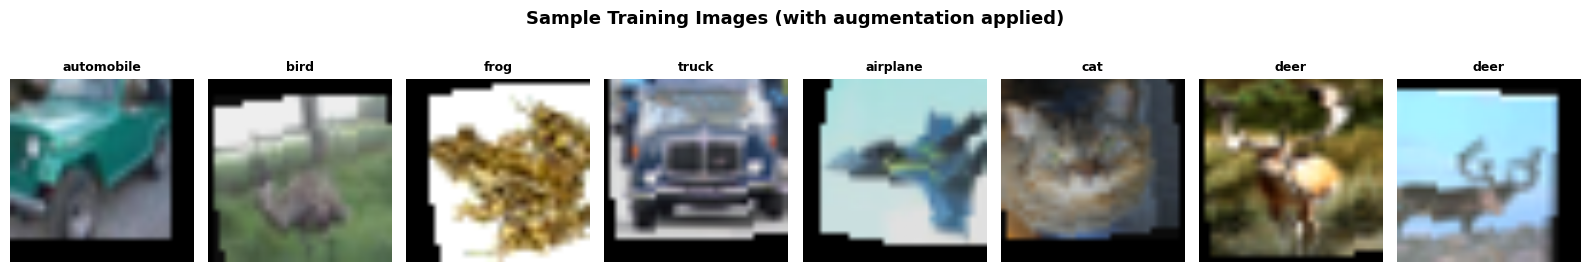

Some images may look rotated/flipped because of augmentation!


In [9]:
def denormalize(tensor):

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)

    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    return (tensor * std) + mean


# Get one batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(16, 3))

for i in range(8):

    img = denormalize(images[i]).permute(1, 2, 0).numpy()

    img = np.clip(img, 0, 1)

    axes[i].imshow(img)

    axes[i].set_title(
        class_names[labels[i].item()],
        fontsize=9,
        fontweight='bold'
    )

    axes[i].axis('off')

plt.suptitle(
    'Sample Training Images (with augmentation applied)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

print('Some images may look rotated/flipped because of augmentation!')

# **Section 3: Building the Model**

# ─── Cell 8: Load pretrained ResNet18 and adapt for 10-class output ──

In [11]:
# Load pretrained ResNet18
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Original final layer
print('Original final layer (fc):', model.fc)

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

print('All pretrained layers frozen.')

# Replace final layer
NUM_CLASSES = 10

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

print(f'New final layer: {model.fc}')

# Move model to GPU/CPU
model = model.to(device)

# Count parameters
trainable = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel() for p in model.parameters()
)

print(f'Trainable parameters : {trainable:,}')
print(f'Frozen parameters    : {total-trainable:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s] 


Original final layer (fc): Linear(in_features=512, out_features=1000, bias=True)
All pretrained layers frozen.
New final layer: Linear(in_features=512, out_features=10, bias=True)
Trainable parameters : 5,130
Frozen parameters    : 11,176,512


# ─── Cell 9: Configure training components ────

In [12]:
# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print('Training components ready!')

print('Loss Function : CrossEntropyLoss')
print('Optimizer     : Adam')
print('Learning Rate : 0.001')

Training components ready!
Loss Function : CrossEntropyLoss
Optimizer     : Adam
Learning Rate : 0.001


# **Section 4: Training the Classifier**

# ─── Cell 10: Training and evaluation functions ───

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        if batch_idx % 50 == 0:
            print(
                f'Batch {batch_idx}/{len(loader)} | Loss: {loss.item():.4f}'
            )

    avg_loss = total_loss / len(loader)

    accuracy = 100.0 * correct / total

    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)

    accuracy = 100.0 * correct / total

    return avg_loss, accuracy


print('Training and evaluation functions defined!')

Training and evaluation functions defined!


# ─── Cell 11: Main training loop ─────

In [14]:
NUM_EPOCHS = 10

best_val_acc = 0.0

history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

print('=' * 60)
print('STARTING TRAINING')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):

    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')
    print('-' * 40)

    # Training
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validation
    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    # Scheduler
    scheduler.step(val_loss)

    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Print results
    print(f'Train Loss: {train_loss:.4f}')
    print(f'Train Accuracy: {train_acc:.2f}%')

    print(f'Val Loss: {val_loss:.4f}')
    print(f'Val Accuracy: {val_acc:.2f}%')

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            'best_model.pth'
        )

        print(f'NEW BEST MODEL SAVED!')

print('\nTRAINING COMPLETE!')
print(f'Best Validation Accuracy: {best_val_acc:.2f}%')

STARTING TRAINING

Epoch 1/10
----------------------------------------
Batch 0/125 | Loss: 2.4324
Batch 50/125 | Loss: 1.7633
Batch 100/125 | Loss: 1.4621
Train Loss: 1.7694
Train Accuracy: 40.38%
Val Loss: 1.3642
Val Accuracy: 59.80%
NEW BEST MODEL SAVED!

Epoch 2/10
----------------------------------------
Batch 0/125 | Loss: 1.5933
Batch 50/125 | Loss: 1.1321
Batch 100/125 | Loss: 1.3813
Train Loss: 1.2420
Train Accuracy: 59.62%
Val Loss: 1.1280
Val Accuracy: 62.70%
NEW BEST MODEL SAVED!

Epoch 3/10
----------------------------------------
Batch 0/125 | Loss: 1.4316
Batch 50/125 | Loss: 1.1811
Batch 100/125 | Loss: 1.0303
Train Loss: 1.0960
Train Accuracy: 62.83%
Val Loss: 1.0209
Val Accuracy: 64.10%
NEW BEST MODEL SAVED!

Epoch 4/10
----------------------------------------
Batch 0/125 | Loss: 1.0680
Batch 50/125 | Loss: 1.0453
Batch 100/125 | Loss: 0.8636
Train Loss: 1.0312
Train Accuracy: 65.65%
Val Loss: 1.0176
Val Accuracy: 64.80%
NEW BEST MODEL SAVED!

Epoch 5/10
--------------

# ─── Cell 12: Plot training curves ────

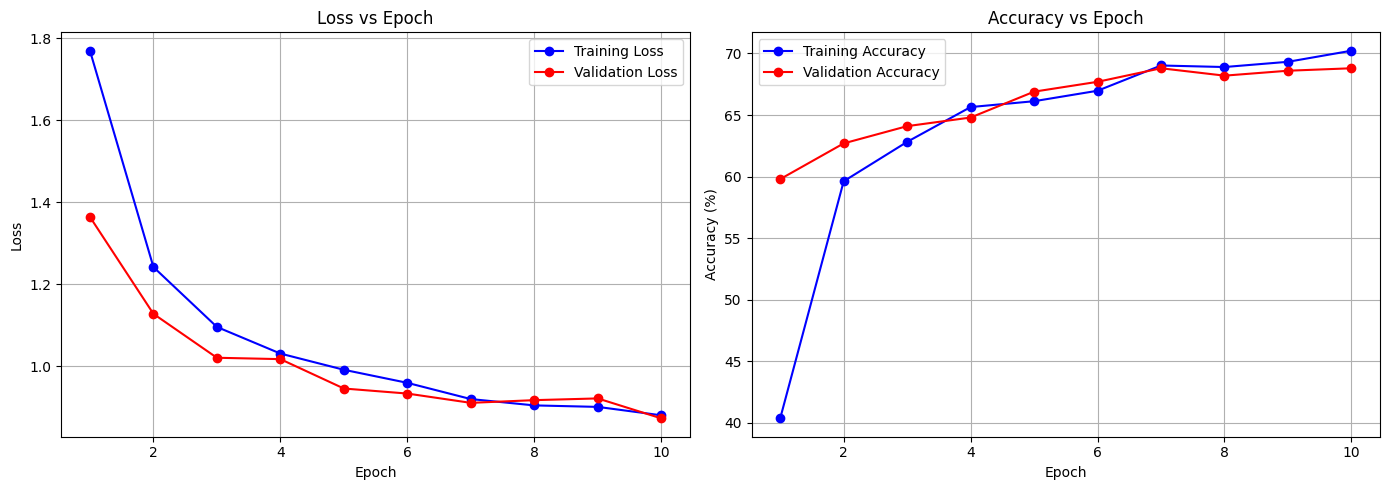

Train-Val Gap: 1.42%


In [16]:
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

epochs_range = range(1, NUM_EPOCHS + 1)

# Loss plot
ax1.plot(
    epochs_range,
    history['train_loss'],
    'b-o',
    label='Training Loss'
)

ax1.plot(
    epochs_range,
    history['val_loss'],
    'r-o',
    label='Validation Loss'
)

ax1.set_title('Loss vs Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(
    epochs_range,
    history['train_acc'],
    'b-o',
    label='Training Accuracy'
)

ax2.plot(
    epochs_range,
    history['val_acc'],
    'r-o',
    label='Validation Accuracy'
)

ax2.set_title('Accuracy vs Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

plt.savefig('training_curves.png')

plt.show()

# Overfitting check
final_gap = (
    history['train_acc'][-1]
    - history['val_acc'][-1]
)

print(f'Train-Val Gap: {final_gap:.2f}%')

# **Section 5: Model Evaluation**

# ─── Cell 13: TEST EVALUATION ────

In [15]:
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)

print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

print('\nClassification Report:\n')

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=3
))

Test Accuracy: 0.7630 (76.30%)

Classification Report:

              precision    recall  f1-score   support

    airplane      0.743     0.810     0.775       100
  automobile      0.800     0.880     0.838       100
        bird      0.613     0.760     0.679       100
         cat      0.647     0.550     0.595       100
        deer      0.808     0.630     0.708       100
         dog      0.714     0.800     0.755       100
        frog      0.793     0.880     0.834       100
       horse      0.780     0.780     0.780       100
        ship      0.938     0.750     0.833       100
       truck      0.868     0.790     0.827       100

    accuracy                          0.763      1000
   macro avg      0.770     0.763     0.762      1000
weighted avg      0.770     0.763     0.762      1000



# ─── Cell 14: CONFUSION MATRIX ────

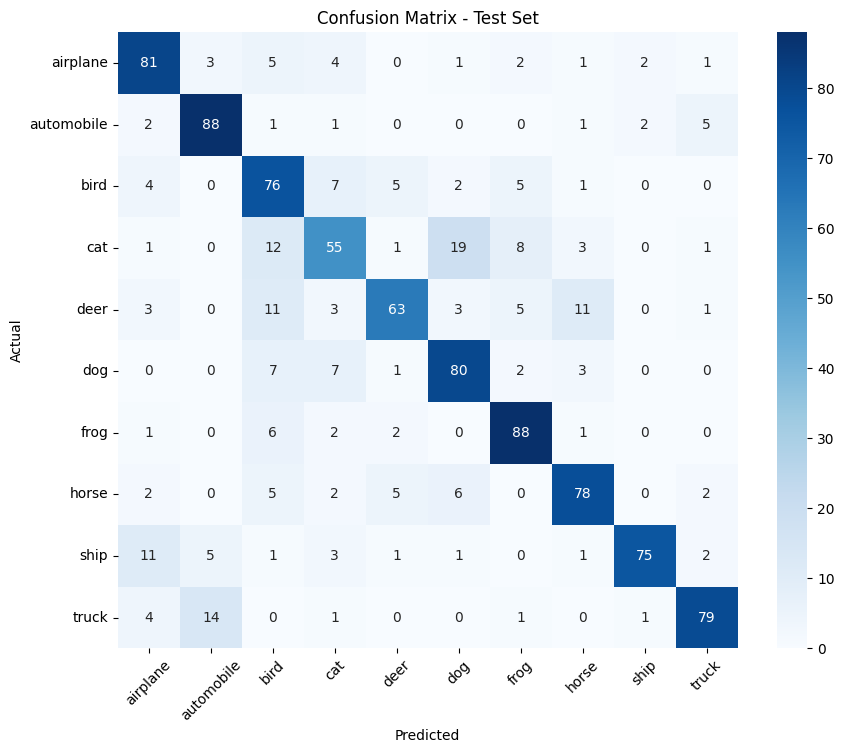

Most confused pair:
True class: cat
Predicted as: dog
Confusions: 19

Per-class accuracy:

airplane    : 81.00%
automobile  : 88.00%
bird        : 76.00%
cat         : 55.00%
deer        : 63.00%
dog         : 80.00%
frog        : 88.00%
horse       : 78.00%
ship        : 75.00%
truck       : 79.00%


In [17]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# Most confused pair
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

worst = np.unravel_index(cm_copy.argmax(), cm_copy.shape)

print("Most confused pair:")
print("True class:", class_names[worst[0]])
print("Predicted as:", class_names[worst[1]])
print("Confusions:", cm_copy[worst])

# Per-class accuracy
per_class = cm.diagonal() / cm.sum(axis=1)

print("\nPer-class accuracy:\n")

for i, name in enumerate(class_names):
    print(f"{name:12s}: {per_class[i]*100:.2f}%")

# **Section 6: Predicting New Images**

# ─── Cell 15: TEST BATCH PREDICTIONS ────

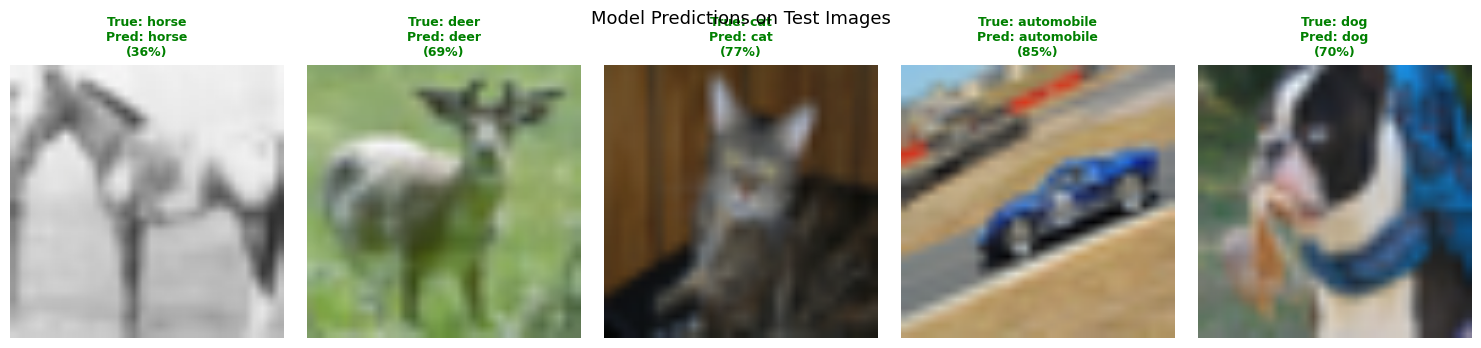

In [18]:
test_images, test_labels = next(iter(test_loader))

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))

model.eval()

for i in range(5):

    img_display = denormalize(test_images[i]).permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)

    single_input = test_images[i].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(single_input)
        prob = torch.nn.functional.softmax(output[0], dim=0)

        pred = torch.argmax(prob).item()
        conf = prob[pred].item()

    true_lbl = class_names[test_labels[i].item()]
    pred_lbl = class_names[pred]

    color = 'green' if pred == test_labels[i].item() else 'red'

    axes[i].imshow(img_display)

    axes[i].set_title(
        f'True: {true_lbl}\nPred: {pred_lbl}\n({conf:.0%})',
        fontsize=9,
        fontweight='bold',
        color=color
    )

    axes[i].axis('off')

plt.suptitle('Model Predictions on Test Images', fontsize=13)
plt.tight_layout()
plt.show()

# ─── Cell 16: IMAGE PREDICTION FUNCTION ────

In [19]:
def predict_image(image_path, model, class_names, device):

    image = Image.open(image_path).convert('RGB')

    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    tensor = preprocess(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        outputs = model(tensor)

    probs = torch.nn.functional.softmax(outputs[0], dim=0)

    confidence, pred_idx = torch.max(probs, dim=0)

    predicted_class = class_names[pred_idx.item()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.imshow(image)
    ax1.set_title(
        f'Predicted: {predicted_class}\nConfidence: {confidence.item():.1%}',
        fontsize=12,
        fontweight='bold'
    )
    ax1.axis('off')

    top5_probs, top5_idx = torch.topk(probs, 5)

    top5_names = [class_names[i.item()] for i in top5_idx]
    top5_values = [p.item() * 100 for p in top5_probs]

    ax2.barh(top5_names[::-1], top5_values[::-1])

    ax2.set_title('Top 5 Predictions')

    plt.tight_layout()
    plt.show()

    return predicted_class, confidence.item()

print("predict_image function ready")

predict_image function ready


# ─── Cell 17: TEST ON SAVED IMAGE ────

True class: horse


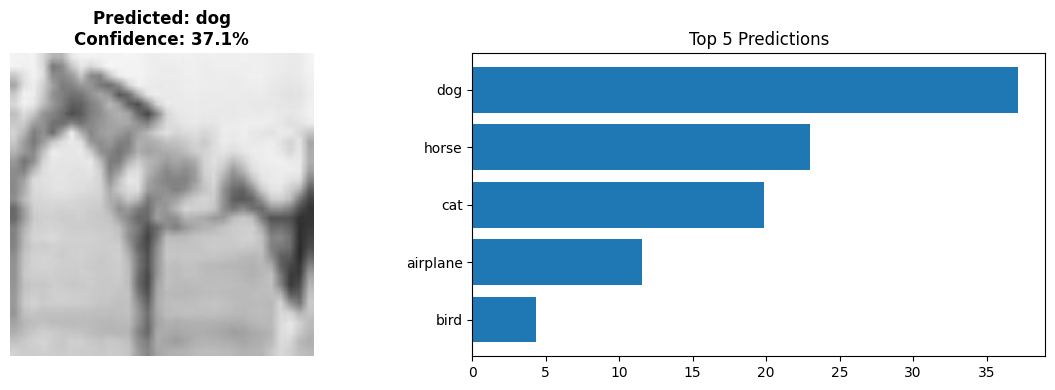

Predicted: dog
Confidence: 37.1%
WRONG


In [20]:
sample_img, sample_label = test_dataset[0]

sample = denormalize(sample_img).permute(1, 2, 0).numpy()
sample = np.clip(sample * 255, 0, 255).astype(np.uint8)

img = Image.fromarray(sample)
img.save("sample.jpg")

true_class = class_names[sample_label]

print("True class:", true_class)

pred, conf = predict_image("sample.jpg", model, class_names, device)

print("Predicted:", pred)
print("Confidence:", f"{conf:.1%}")

if pred == true_class:
    print("CORRECT")
else:
    print("WRONG")

# ─── Cell 18: SAVE & LOAD CHECKPOINT ─────

In [21]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc': best_val_acc,
    'class_names': class_names,
    'num_classes': NUM_CLASSES,
    'history': history
}

torch.save(checkpoint, "cifar10_checkpoint.pth")

print("Checkpoint saved")

Checkpoint saved


In [23]:
# LOAD MODEL

def load_checkpoint(path, device):

    ckpt = torch.load(path, map_location=device)

    model = models.resnet18(weights=None)

    model.fc = nn.Linear(
        model.fc.in_features,
        ckpt['num_classes']
    )

    model.load_state_dict(ckpt['model_state_dict'])

    model = model.to(device)
    model.eval()

    print("Loaded checkpoint")
    print("Best val acc:", ckpt['best_val_acc'])

    return model, ckpt['class_names']


reloaded_model, reloaded_classes = load_checkpoint(
    "cifar10_checkpoint.pth",
    device
)

print(reloaded_classes)

Loaded checkpoint
Best val acc: 68.8
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
